# 1D-CNN v7 — Enhanced Calibration + All Scenarios (S1-S8)

Loads pre-trained 1dcnn_v6.pt. Calibration: SVM RBF on deep features + weighted ensemble.

## Import


In [14]:
import sys, math
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from config import RANDOM_SEED, N_CLASSES, MODELS_DIR, get_device
from src.experiment_runner import (
    get_splits, load_and_norm,
    run_zero_shot, run_calibration, print_comparison,
    TEST_SUBJECTS, TRAIN_SUBJECTS, META,
)
from src.evaluation import measure_latency, print_latency

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = get_device()
splits = get_splits()
print(f'Device: {DEVICE}')

Device: mps


## Model definition


In [15]:
class ECA1d(nn.Module):
    def __init__(self,ch):
        super().__init__()
        k = max(int(abs(math.log2(ch)/2+0.5)),3); k = k if k%2 else k+1
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1,1,k,padding=k//2,bias=False)
    def forward(self,x):
        b,c,t = x.size()
        return x * torch.sigmoid(self.conv(self.gap(x).view(b,1,c))).view(b,c,1).expand_as(x)

class SepConv1d(nn.Module):
    def __init__(self,ic,oc,k=5,p=2):
        super().__init__()
        self.dw = nn.Conv1d(ic,ic,k,padding=p,groups=ic)
        self.pw = nn.Conv1d(ic,oc,1)
    def forward(self,x): return self.pw(self.dw(x))

class TemporalSCNN(nn.Module):
    def __init__(self,in_ch=8,n_classes=N_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_ch,64,5,padding=2), nn.BatchNorm1d(64), nn.ReLU(), ECA1d(64), nn.MaxPool1d(2),
            SepConv1d(64,128,5,2), nn.BatchNorm1d(128), nn.ReLU(), ECA1d(128), nn.MaxPool1d(2),
            SepConv1d(128,256,3,1), nn.BatchNorm1d(256), nn.ReLU(), ECA1d(256), nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3), nn.Linear(256,64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64,n_classes),
        )
    def forward(self,x): return self.classifier(self.features(x))
    def extract_feat(self,x):
        with torch.no_grad(): return nn.Flatten()(self.features(x))

print(f'Params: {sum(p.numel() for p in TemporalSCNN().parameters()):,}')

Params: 62,676


## Load pre-trained model


In [16]:
train_combined = pd.concat([splits['train_df'], splits['s5_train']])
X_train, y_train, norm_stats = load_and_norm(train_combined, verbose=True)
print(f'Train: {X_train.shape}')

model = TemporalSCNN().to(DEVICE)
model.load_state_dict(torch.load(MODELS_DIR / '1dcnn_v6.pt', map_location=DEVICE))
model.eval()
print('Loaded 1dcnn_v6.pt')

Loading windows: 100%|██████████| 9021/9021 [00:07<00:00, 1174.80it/s]


Train: (1030712, 8, 50)
Loaded 1dcnn_v6.pt


## Predict + feature extraction


In [17]:
@torch.no_grad()
def base_predict(X):
    model.eval()
    loader = DataLoader(TensorDataset(torch.from_numpy(X).float()), batch_size=512, shuffle=False)
    return np.concatenate([model(xb[0].to(DEVICE)).argmax(1).cpu().numpy() for xb in loader])

@torch.no_grad()
def base_proba(X):
    model.eval()
    loader = DataLoader(TensorDataset(torch.from_numpy(X).float()), batch_size=512, shuffle=False)
    probs = []
    for (xb,) in loader:
        probs.append(torch.softmax(model(xb.to(DEVICE)), dim=1).cpu().numpy())
    return np.concatenate(probs)

@torch.no_grad()
def extract_features(X):
    model.eval()
    loader = DataLoader(TensorDataset(torch.from_numpy(X).float()), batch_size=512, shuffle=False)
    return np.concatenate([model.extract_feat(xb[0].to(DEVICE)).cpu().numpy() for xb in loader])

## Calibration


In [18]:
def calibrate_svm(X_cal, y_cal):
    F_cal = extract_features(X_cal)
    sc = StandardScaler().fit(F_cal)
    svm = SVC(kernel='rbf', C=100, gamma='scale', probability=True, random_state=RANDOM_SEED)
    svm.fit(sc.transform(F_cal), y_cal)
    return svm, sc

def ensemble_predict(X, svm, sc, base_weight=0.3, cal_weight=0.7):
    p_base = base_proba(X)
    p_cal = svm.predict_proba(sc.transform(extract_features(X)))
    return (base_weight * p_base + cal_weight * p_cal).argmax(axis=1)

def full_calibration(X_cal, y_cal, X_test):
    svm, sc = calibrate_svm(X_cal, y_cal)
    return ensemble_predict(X_test, svm, sc)

def cnn1d_finetune(X_cal, y_cal):
    svm, sc = calibrate_svm(X_cal, y_cal)
    def predict_ft(X): return ensemble_predict(X, svm, sc)
    return predict_ft

## S1-S5 Zero-shot


In [19]:
print('Option B -- Zero-shot:')
zero_results = run_zero_shot(base_predict, splits, norm_stats)

Option B -- Zero-shot:
  S1 zero-shot: 0.5862
  S2 zero-shot: 0.5352
  S3 zero-shot: 0.5398
  S4 zero-shot: 0.6556
  S5 zero-shot: 0.8029


## S1-S5 Calibrated


In [20]:
print('Option A -- Calibration (SVM ensemble):')
cal_results = run_calibration(base_predict, cnn1d_finetune, splits, norm_stats)

Option A -- Calibration (SVM ensemble):
  S1 calibrated: 0.7520


KeyboardInterrupt: 

## S1-S5 Results


In [ ]:
print_comparison(zero_results, cal_results, name='1D-CNN (v7)')


  1D-CNN (v7) — RESULTS
Scenario        Zero-shot   Calibrated        Δ
-------------------------------------------------------
S1                58.62%       71.32%   +12.70%
S2                53.52%       76.79%   +23.27%
S3                53.98%       75.97%   +21.99%
S4                65.56%       82.00%   +16.44%
S5                80.29%       86.22% ✓   +5.93%


## S6: Combined Factor


In [ ]:
print('\n=== S6: Combined Factor (Cross-Subject + Shift) ===')
s6_test = META[(META['subject'].isin(TEST_SUBJECTS)) & (META['session']==0) & (META['position']>0)]
X_s6, y_s6, _ = load_and_norm(s6_test, stats=norm_stats)
s6_zs = accuracy_score(y_s6, base_predict(X_s6))
print(f'S6 zero-shot: {s6_zs:.4f}')

s6_cal_accs = []
for subj in TEST_SUBJECTS:
    sdf = s6_test[s6_test['subject']==subj]
    if len(sdf)==0: continue
    cal_df = sdf[sdf['repetition'].isin([0,1])]
    test_df = sdf[sdf['repetition']==2]
    if len(cal_df)==0 or len(test_df)==0: continue
    X_c, y_c, _ = load_and_norm(cal_df, stats=norm_stats)
    X_t, y_t, _ = load_and_norm(test_df, stats=norm_stats)
    y_pred = full_calibration(X_c, y_c, X_t)
    acc = accuracy_score(y_t, y_pred)
    s6_cal_accs.append(acc)
    print(f'  {subj}: {acc:.4f}')
s6_cal = np.mean(s6_cal_accs)
print(f'S6 calibrated avg: {s6_cal:.4f}')


=== S6: Combined Factor (Cross-Subject + Shift) ===
S6 zero-shot: 0.5352
  h7: 0.8601
  h22: 0.7668
  h3: 0.7930
  h24: 0.8388
  h16: 0.8418
  h17: 0.7995
S6 calibrated avg: 0.8167


## S7: Gradual Electrode Shift (h24-h29)



=== S7: Gradual Electrode Shift (h24-h29) ===
  Position  0: 0.7761
  Position  1: 0.8123
  Position  2: 0.7975
  Position  3: 0.8024
  Position  4: 0.7778
  Position  5: 0.8291
  Position  6: 0.8048
  Position  7: 0.7973
  Position  8: 0.7935
  Position  9: 0.8028
  Position 10: 0.7748

P0 baseline: 0.7761, Avg shifted: 0.7992, Degradation: -2.32%


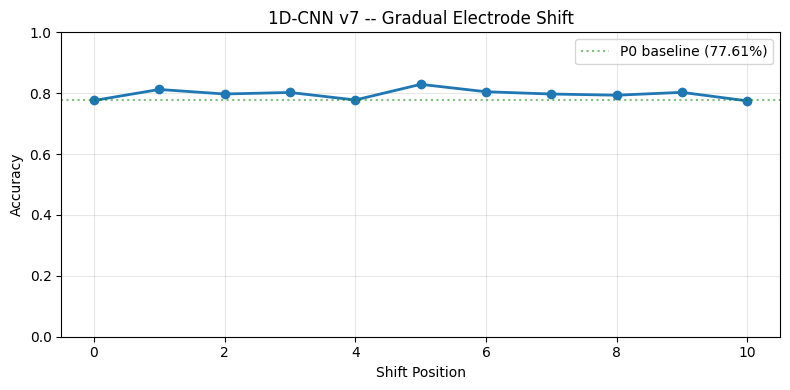

In [ ]:
print('\n=== S7: Gradual Electrode Shift (h24-h29) ===')
shift_subjects = [f'h{i}' for i in range(24, 30)]
shift_data = META[(META['subject'].isin(shift_subjects)) & (META['session']==0)]

s7_acc = {}
for pos in sorted(shift_data['position'].unique()):
    pos_df = shift_data[shift_data['position']==pos]
    X_p, y_p, _ = load_and_norm(pos_df, stats=norm_stats)
    s7_acc[pos] = accuracy_score(y_p, base_predict(X_p))
    print(f'  Position {pos:2d}: {s7_acc[pos]:.4f}')

baseline = s7_acc.get(0, 0)
avg_shifted = np.mean([s7_acc[p] for p in s7_acc if p>0])
print(f'\nP0 baseline: {baseline:.4f}, Avg shifted: {avg_shifted:.4f}, Degradation: {(baseline-avg_shifted)*100:.2f}%')

plt.figure(figsize=(8, 4))
plt.plot(list(s7_acc.keys()), list(s7_acc.values()), 'o-', linewidth=2)
plt.axhline(y=baseline, color='green', ls=':', alpha=0.5, label=f'P0 baseline ({baseline:.2%})')
plt.xlabel('Shift Position')
plt.ylabel('Accuracy')
plt.title('1D-CNN v7 -- Gradual Electrode Shift')
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## S8: Few-Shot Calibration Analysis



=== S8: Few-Shot Calibration Analysis ===
  Zero-shot           : 0.5391  (~0 trials)
  1 rep, p0 only      : 0.3860  (~7 trials)
  1 rep, all pos      : 0.7523  (~77 trials)
  2 rep, p0 only      : 0.4280  (~14 trials)
  2 rep, all pos      : 0.8087  (~154 trials)


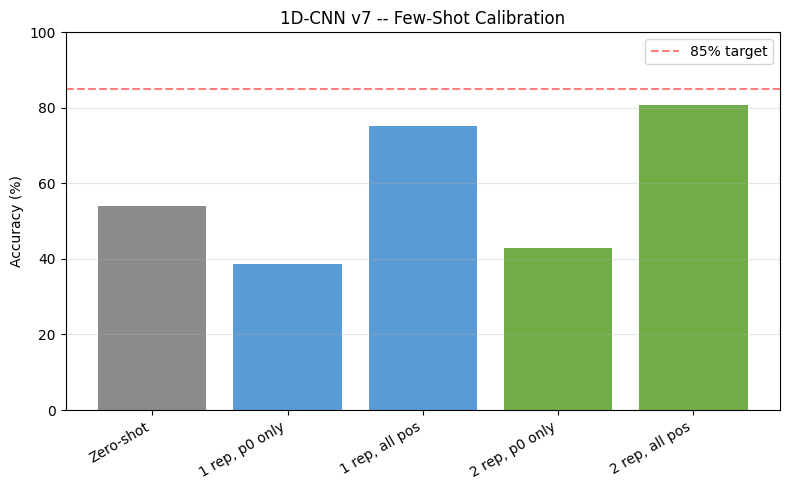

In [ ]:
print('\n=== S8: Few-Shot Calibration Analysis ===')
subset_s8 = META[(META['session']==0) & (META['subject'].isin(TEST_SUBJECTS))]

configs = [
    ('Zero-shot',        [],     False, 0),
    ('1 rep, p0 only',   [0],    True,  7),
    ('1 rep, all pos',   [0],    False, 77),
    ('2 rep, p0 only',   [0,1],  True,  14),
    ('2 rep, all pos',   [0,1],  False, 154),
]

s8_results = {}
for label, reps, p0_only, n_trials in configs:
    accs = []
    for subj in TEST_SUBJECTS:
        sdf = subset_s8[subset_s8['subject']==subj]
        if len(reps)==0:
            X_t, y_t, _ = load_and_norm(sdf, stats=norm_stats)
            accs.append(accuracy_score(y_t, base_predict(X_t)))
            continue
        if p0_only:
            cal_df = sdf[(sdf['repetition'].isin(reps)) & (sdf['position']==0)]
        else:
            cal_df = sdf[sdf['repetition'].isin(reps)]
        test_df = sdf[sdf['repetition']==2]
        if len(cal_df)==0 or len(test_df)==0: continue
        X_c, y_c, _ = load_and_norm(cal_df, stats=norm_stats)
        X_t, y_t, _ = load_and_norm(test_df, stats=norm_stats)
        y_pred = full_calibration(X_c, y_c, X_t)
        accs.append(accuracy_score(y_t, y_pred))
    s8_results[label] = np.mean(accs)
    print(f'  {label:<20s}: {s8_results[label]:.4f}  (~{n_trials} trials)')

plt.figure(figsize=(8, 5))
labels = list(s8_results.keys())
vals = [v*100 for v in s8_results.values()]
bar_colors = ['#8B8B8B'] + ['#5B9BD5']*2 + ['#70AD47']*2
plt.bar(range(len(labels)), vals, color=bar_colors)
plt.axhline(y=85, color='red', ls='--', alpha=0.5, label='85% target')
plt.xticks(range(len(labels)), labels, rotation=30, ha='right')
plt.ylabel('Accuracy (%)')
plt.title('1D-CNN v7 -- Few-Shot Calibration')
plt.ylim(0, 100)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Latency


In [ ]:
model.eval()
s = torch.randn(1,8,50).to(DEVICE)
for _ in range(10): _ = model(s)
if DEVICE.type=='mps': torch.mps.synchronize()
def cnn1d_single(x):
    xt = torch.from_numpy(x).float().to(DEVICE)
    with torch.no_grad(): out = model(xt)
    if DEVICE.type=='mps': torch.mps.synchronize()
    return out.argmax(1).cpu().numpy()
latency = measure_latency(cnn1d_single, X_train[:1], n_runs=500)
print_latency(latency, '1D-CNN v7')


Latency — 1D-CNN v7
  Mean:   2.94 ms
  Median: 2.88 ms
  P95:    3.08 ms
  <300ms: ✓


## Full Summary


In [ ]:
print('\n' + '='*60)
print('  1D-CNN v7 -- FULL RESULTS')
print('='*60)
print(f'{"Scenario":<25} {"Zero-shot":>12} {"Calibrated":>12}')
print('-'*60)
for s in ['S1','S2','S3','S4','S5']:
    print(f'{s:<25} {zero_results[s]*100:>10.2f}%  {cal_results[s]*100:>10.2f}%')
print(f'{"S6 Combined":<25} {s6_zs*100:>10.2f}%  {s6_cal*100:>10.2f}%')
print(f'{"S7 Gradual (avg p1-10)":<25} {avg_shifted*100:>10.2f}%  {"--":>12}')
for label, val in s8_results.items():
    if label == 'Zero-shot': continue
    print(f'{"S8 " + label:<25} {"--":>12}  {val*100:>10.2f}%')
print(f'{"Latency p95 (ms)":<25} {latency["p95_ms"]:>10.2f}')
print(f'{"Parameters":<25} {"62,676":>12}')
print('='*60)


  1D-CNN v7 -- FULL RESULTS
Scenario                     Zero-shot   Calibrated
------------------------------------------------------------
S1                             58.62%       71.32%
S2                             53.52%       76.79%
S3                             53.98%       75.97%
S4                             65.56%       82.00%
S5                             80.29%       86.22%
S6 Combined                    53.52%       81.67%
S7 Gradual (avg p1-10)         79.92%            --
S8 1 rep, p0 only                   --       38.60%
S8 1 rep, all pos                   --       75.23%
S8 2 rep, p0 only                   --       42.80%
S8 2 rep, all pos                   --       80.87%
Latency p95 (ms)                3.08
Parameters                      62,676
